In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image 
from wordcloud import WordCloud

# 한글 폰트 설정 (폰트 깨짐 방지 - 환경에 맞게 선택)
plt.rc('font', family='Malgun Gothic') # 윈도우용
plt.rc('axes', unicode_minus=False)

In [3]:
# 1. data 폴더 안의 모든 CSV 파일 경로 가져오기
# (만약 특정 패턴의 파일만 가져오고 싶다면 'data/*_이혼_연간자료.csv' 처럼 수정 가능)
file_paths = glob.glob('data/*_이혼_연간자료.csv')

# 2. 각 파일을 반복문으로 읽어서 리스트에 담기 (인코딩 설정 유지)
df_list = []
for file in file_paths:
    df = pd.read_csv(file, encoding='euc-kr')
    df_list.append(df)

In [4]:
df_list

[        시도코드  실제결혼연도  실제이혼연도  20세미만자녀수코드  이혼종류코드  이혼사유코드  남편교육정도코드  아내교육정도코드  \
 0         11    1948    2013           0       2      27         4         4   
 1         11    1949    2013           0       2      21         1         1   
 2         11    1951    2013           0       1      25         3         2   
 3         11    1956    2013           0       1      23         2         2   
 4         11    1956    2013           0       1      25         2         3   
 ...      ...     ...     ...         ...     ...     ...       ...       ...   
 115287    89    1997    2005           0       2      27         4         4   
 115288    89    1999    2003           0       2      27         4         4   
 115289    89    2004    2013           0       2      27         3         3   
 115290    89    2008    2013           0       2      27         3         4   
 115291    89    1987    2013           0       2      27         4         4   
 
         남편결혼연령  아내결혼연령  남

In [5]:

# 3. 같은 컬럼을 기준으로 위아래로 이어 붙이기 (인덱스 재정렬)
combined_data = pd.concat(df_list, ignore_index=True)

# 4. 결과 확인
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1345910 entries, 0 to 1345909
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   시도코드        1345910 non-null  int64
 1   실제결혼연도      1345910 non-null  int64
 2   실제이혼연도      1345910 non-null  int64
 3   20세미만자녀수코드  1345910 non-null  int64
 4   이혼종류코드      1345910 non-null  int64
 5   이혼사유코드      1345910 non-null  int64
 6   남편교육정도코드    1345910 non-null  int64
 7   아내교육정도코드    1345910 non-null  int64
 8   남편결혼연령      1345910 non-null  int64
 9   아내결혼연령      1345910 non-null  int64
 10  남편이혼연령      1345910 non-null  int64
 11  아내이혼연령      1345910 non-null  int64
 12  동거기간년수      1345910 non-null  int64
dtypes: int64(13)
memory usage: 133.5 MB


In [6]:
combined_data.isna().sum()

시도코드          0
실제결혼연도        0
실제이혼연도        0
20세미만자녀수코드    0
이혼종류코드        0
이혼사유코드        0
남편교육정도코드      0
아내교육정도코드      0
남편결혼연령        0
아내결혼연령        0
남편이혼연령        0
아내이혼연령        0
동거기간년수        0
dtype: int64

In [7]:
combined_data

,시도코드,실제결혼연도,실제이혼연도,20세미만자녀수코드,이혼종류코드,이혼사유코드,남편교육정도코드,아내교육정도코드,남편결혼연령,아내결혼연령,남편이혼연령,아내이혼연령,동거기간년수
0,11,1948,2013,0,2,27,4,4,24,19,85,83,64
1,11,1949,2013,0,2,21,1,1,17,17,82,82,64
2,11,1951,2013,0,1,25,3,2,15,11,77,73,61
3,11,1956,2013,0,1,23,2,2,22,22,79,79,56
4,11,1956,2013,0,1,25,2,3,25,20,83,77,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345905,31,2024,2025,0,1,0,4,5,37,29,39,31,1
1345906,81,2025,2025,0,2,0,4,3,35,39,35,39,0
1345907,32,2025,2025,0,2,0,5,4,57,31,58,32,0
1345908,38,2025,2025,0,2,0,6,2,54,29,54,29,0


## 현재 데이터 구조 파악 (combined_data)
- 화면에 오픈된 데이터셋의 주요 컬럼들은 가설 검증에 완벽히 매칭됩니다.
- 실제결혼연도, 실제이혼연도, 동거기간년수 (가설 1, 3 검증용)
- 이혼사유코드, 20세미만자녀수코드, 남편/아내교육정도코드 (가설 2 검증용)
- 남편/아내결혼연령, 남편/아내이혼연령 (가설 3 검증용)

🔍가설 1: 신혼 부부(혼인기간 5년 이하)의 이혼 비율이 가장 높을 것이다?
- 핵심 포인트: 제시하신 의견대로 **'단순 이혼 건수'**와 통계청의 '조혼인율(해당 연도별 혼인 진입 인구)' 기저 데이터를 결합하여 비율을 산출해야 통계적 착시를 막을 수 있습니다. 신혼 이혼이 많은지, 아니면 황혼 이혼(20년~30년 이상) 추세가 역전했는지 비교합니다.

- 분석 방법:
1. 동거기간년수 컬럼을 활용해 구간화(Binning)를 수행합니다.(0 ~ 5년: 신혼, 6 ~ 10년, 15 ~ 20년, 21 ~ 25년, 26 ~ 30년,  30년 이상: 황혼)

2. 전체 이혼 건수 중 '5년 이하'가 차지하는 단순 비율을 파이썬 카운트로 계산합니다.

3. 발전 방향: 한계점 극복을 위해 통계청 kosis에서 동기간 '연도별 총 혼인 건수' 인구 통계를 가져와,
각 혼인 코호트(진입기) 대비 이혼율을 매칭하는 정규화 작업을 시도합니다.

In [8]:
# 1. 혼인 기간 구간화
bins = [-1, 5, 10, 15, 20, 25, 30, 100]
labels = ['신혼(5년이하)', '6~10년', '11~15년', '16~20년', '21~25년', '26~30년', '황혼(30년초과)']
combined_data['혼인기간구간'] = pd.cut(combined_data['동거기간년수'], bins=bins, labels=labels)

# 2. 비율 계산 및 시각화
print(combined_data['혼인기간구간'].value_counts(normalize=True))

혼인기간구간
신혼(5년이하)     0.246618
6~10년        0.175043
11~15년       0.140008
16~20년       0.129190
황혼(30년초과)    0.117882
21~25년       0.112371
26~30년       0.078889
Name: proportion, dtype: float64


📊 가설 1 시각화: 혼인기간별 이혼 건수 및 비율 (신혼 부부 검증)
- 가설 1을 검증하기 위해서는 전체 이혼 가구 중 '신혼(5년 이하)'의 비중이 얼마나 큰지를 시각적으로 보여주어야 합니다.
- 범주별 비율을 직관적으로 보여주는 파이 차트(Pie Chart)와 실제 건수를 보여주는 카운트 플롯(Count Plot)의 결합이 가장 효과적입니다.

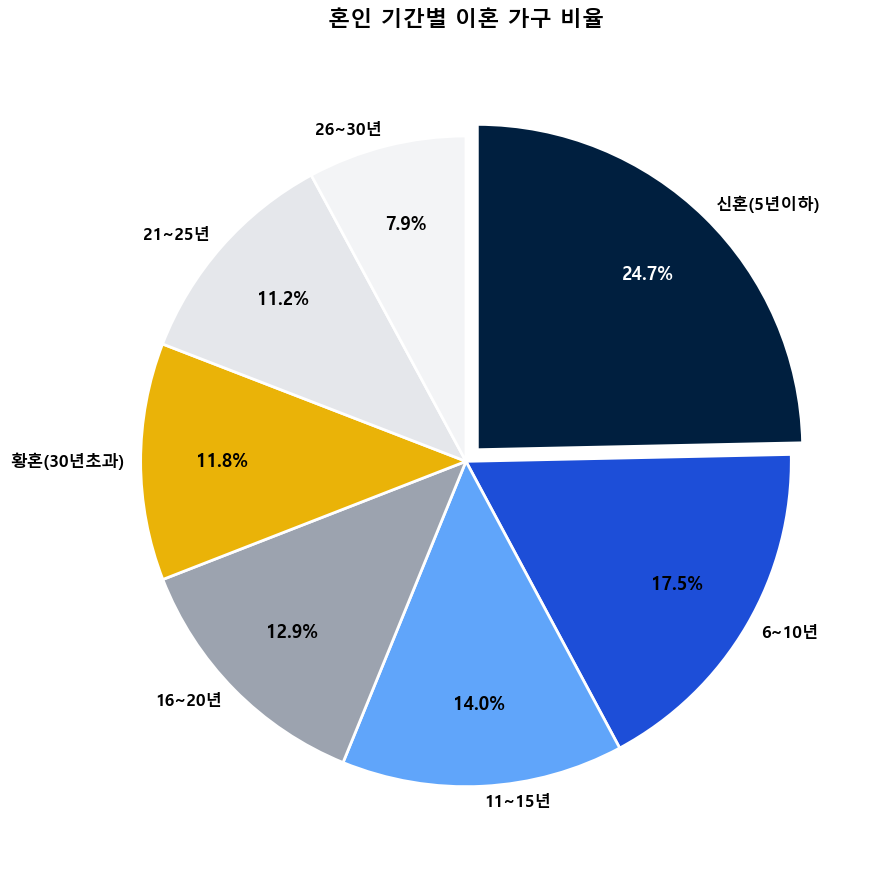

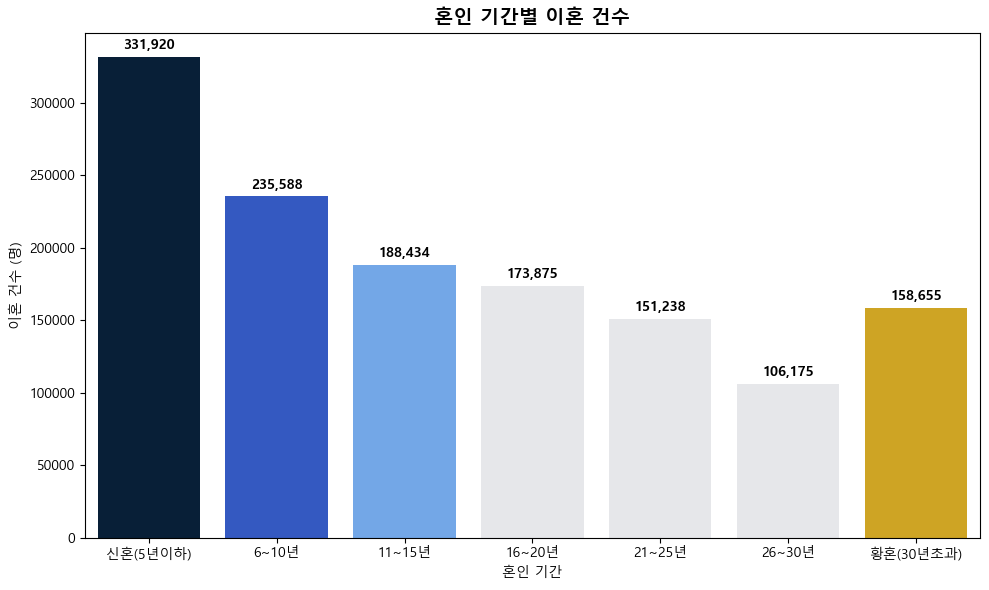

In [9]:
# 1. 데이터 전처리
bins = [-1, 5, 10, 15, 20, 25, 30, 100]
labels = ['신혼(5년이하)', '6~10년', '11~15년', '16~20년', '21~25년', '26~30년', '황혼(30년초과)']

combined_data['혼인기간구간'] = pd.cut(combined_data['동거기간년수'], bins=bins, labels=labels)
df_counts = combined_data['혼인기간구간'].value_counts()


# ==========================================
# [차트 1] 파이 차트: 비율 확인 (황혼 구간 황색 적용)
# ==========================================
plt.figure(figsize=(9, 9))

# 내림차순 정렬 (1위: 신혼, 2위: 6~10년, 3위: 11~15년, 4위: 16~20년, 5위: 황혼..., 등)
df_counts_sorted = df_counts.sort_values(ascending=False)

# 파이 차트 범주 순서에 맞춰 색상 지정
pie_colors = []
for label in df_counts_sorted.index:
    if label == '황혼(30년초과)':
        pie_colors.append('#EAB308')  # 막대 그래프와 동일한 황색 계열
    else:
        # 내림차순 순위 기준으로 남색~회색 그라데이션 적용
        rank = list(df_counts_sorted.index).index(label)
        default_colors = ['#001F3F', '#1D4ED8', '#60A5FA', '#9CA3AF', '#D1D5DB', '#E5E7EB', '#F3F4F6']
        pie_colors.append(default_colors[rank])

explode_pie = [0.05 if i == 0 else 0 for i in range(len(df_counts_sorted))]

patches, texts, autotexts = plt.pie(
    df_counts_sorted,
    labels=df_counts_sorted.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    colors=pie_colors,
    explode=explode_pie,
    pctdistance=0.75,
    labeldistance=1.05,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.0, 'antialiased': True}
)

# 텍스트 스타일 지정
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

for i, autotext in enumerate(autotexts):
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')
    # 1위(짙은 남색)만 흰색 글씨, 나머지는 검은색 글씨
    if i == 0:
        autotext.set_color('white')
    else:
        autotext.set_color('black')

plt.title('혼인 기간별 이혼 가구 비율', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.savefig('case1_01.png', dpi=300, bbox_inches='tight')
plt.show()


# ==========================================
# [차트 2] 막대 차트: 혼인기간별 이혼 건수
# ==========================================
plt.figure(figsize=(10, 6))

rank_colors = ['#001F3F', '#1D4ED8', '#60A5FA'] + ['#E5E7EB'] * (len(df_counts) - 3)
rank_indices = df_counts.rank(ascending=False, method='first').astype(int) - 1

bar_colors = [rank_colors[rank_indices[label]] for label in labels]

# '황혼(30년초과)' 구간 황색 지정
twilight_index = labels.index('황혼(30년초과)')
bar_colors[twilight_index] = '#EAB308'

ax = sns.countplot(
    data=combined_data,
    x='혼인기간구간',
    order=labels,
    palette=bar_colors,
    hue='혼인기간구간',
    legend=False
)

plt.title('혼인 기간별 이혼 건수', fontsize=14, weight='bold')
plt.xlabel('혼인 기간')
plt.ylabel('이혼 건수 (명)')

for p in ax.patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        ax.annotate(
            f'{int(height):,}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontsize=10,
            weight='bold'
        )

plt.tight_layout()
plt.savefig('case1_02.png', dpi=300, bbox_inches='tight')
plt.show()

📈 가설 1 그래프 데이터 분석 및 팩트 체크 리포트
출력된 그래프 결과를 바탕으로 발표 장표나 보고서에 바로 활용할 수 있는 분석 핵심을 도출해 보았습니다.

1. 팩트 체크 결과: "가설 1은 참(맞다)"
- "단일 5년차 구간 중에서는 결혼 직후 초기에 갈라서는 비율이 가장 높다"는 사실을 증명할 수 있습니다.

2. 여전히 강력한 황혼 이혼 및 중장년층 추세
- 신혼이 1위이긴 하지만, 20년 초과 전체(황혼 + 21 ~ 30년)를 합산하면 약 30.9%(11.8% + 11.2% + 7.9%)에 달합니다.
- 11년 차부터 30년 차 이상까지의 범중장년층 이혼을 모두 더하면 전체의 과반을 훌쩍 넘기 때문에, "신혼 이혼이 압도적 대세"라기보다는 "초기 이혼 정점 후 완만하게 감소하다가, 30년이 지나면서 다시 반등(11.8%)하는 U자형 혹은 지속형 흐름"으로 해석하는 것이 매끄럽습니다.


⚠️ 시각화 결과의 함정과 데이터 한계성 제시 문구 예시
- "구간을 5년 단위로 세분화했을 때 '5년 이하 신혼 이혼'이 24.7%로 가장 높은 비중을 차지하는 것으로 나타났습니다. 하지만 이 또한 완벽한 팩트로 보기에는 '모수(분모)의 착시'라는 한계가 존재합니다.
- 최근 5년간 결혼한 신혼부부 총수와 20~30년 전 결혼했던 부부의 총수(진입 모수)가 다르기 때문에, 단순 이혼 건수 비율만으로 '신혼때 가장 이혼을 많이 한다'고 단정할 수 없습니다. 따라서 다음 단계에서는 통계청의 연도별 혼인 코호트 데이터를 결합하여 정규화된 이혼율을 산출하고자 합니다."

In [10]:

# 1. 1970-2025 혼인 연간건수 CSV 파일 가져오기
marriage_data = pd.read_csv('data/1970-2025_혼인_연간건수.csv', encoding='euc-kr')

# 2. 기준년을 '실제이혼연도' 또는 '이혼연도'로 설정 (데이터가 발생한 시점)
if '실제이혼연도' in combined_data.columns:
    combined_data['기준연도'] = combined_data['실제이혼연도']
else:
    combined_data['기준연도'] = combined_data['이혼연도']

# 3. 1970~2025년 사이에 발생한 '모든' 이혼 데이터 유지 (동거기간 64년 포함됨)
analysis_data = combined_data[
    (combined_data['기준연도'] >= 2013) & (combined_data['기준연도'] <= 2025)
].copy()

# 4. 혼인기간 구간화 (동거기간 기준)
bins = [-1, 5, 10, 15, 20, 25, 30, 100]
labels = ['신혼(5년이하)', '6~10년', '11~15년', '16~20년', '21~25년', '26~30년', '황혼(30년초과)']
analysis_data['혼인기간구간'] = pd.cut(analysis_data['동거기간년수'], bins=bins, labels=labels)

# 5. 이혼 발생연도(기준연도)별 + 혼인기간구간별 이혼 건수 집계
divorce_by_year = analysis_data.groupby(['기준연도', '혼인기간구간'], observed=False).size().reset_index(name='이혼건수')

# 6. 기준연도와 혼인 연간건수의 '실제결혼연도'를 매핑하여 결합 (2013년 이혼을 2013년 혼인건수로 나눔)
normalized_df = pd.merge(
    divorce_by_year, 
    marriage_data, 
    left_on='기준연도', 
    right_on='실제결혼연도', 
    how='inner'
)

# 7. 정규화 비율 산출 (%)
normalized_df['정규화이혼율'] = (normalized_df['이혼건수'] / normalized_df['총혼인건수']) * 100

# 8. 결과 확인
normalized_df = normalized_df.drop(columns=['실제결혼연도']).rename(columns={'기준연도': '이혼연도'})
normalized_df = normalized_df.sort_values(by=['이혼연도', '혼인기간구간']).reset_index(drop=True)
print(normalized_df.head(20))

    이혼연도     혼인기간구간   이혼건수   총혼인건수    정규화이혼율
0   2013   신혼(5년이하)  30790  322807  9.538207
1   2013      6~10년  19139  322807  5.928930
2   2013     11~15년  16057  322807  4.974180
3   2013     16~20년  16249  322807  5.033658
4   2013     21~25년  12985  322807  4.022527
5   2013     26~30년   7586  322807  2.350011
6   2013  황혼(30년초과)   8043  322807  2.491582
7   2014   신혼(5년이하)  30348  305507  9.933651
8   2014      6~10년  19619  305507  6.421784
9   2014     11~15년  15655  305507  5.124269
10  2014     16~20년  16134  305507  5.281057
11  2014     21~25년  13006  305507  4.257186
12  2014     26~30년   7729  305507  2.529893
13  2014  황혼(30년초과)   9026  305507  2.954433
14  2015   신혼(5년이하)  28056  302828  9.264665
15  2015      6~10년  18472  302828  6.099832
16  2015     11~15년  14135  302828  4.667666
17  2015     16~20년  15106  302828  4.988310
18  2015     21~25년  12364  302828  4.082846
19  2015     26~30년   7516  302828  2.481937


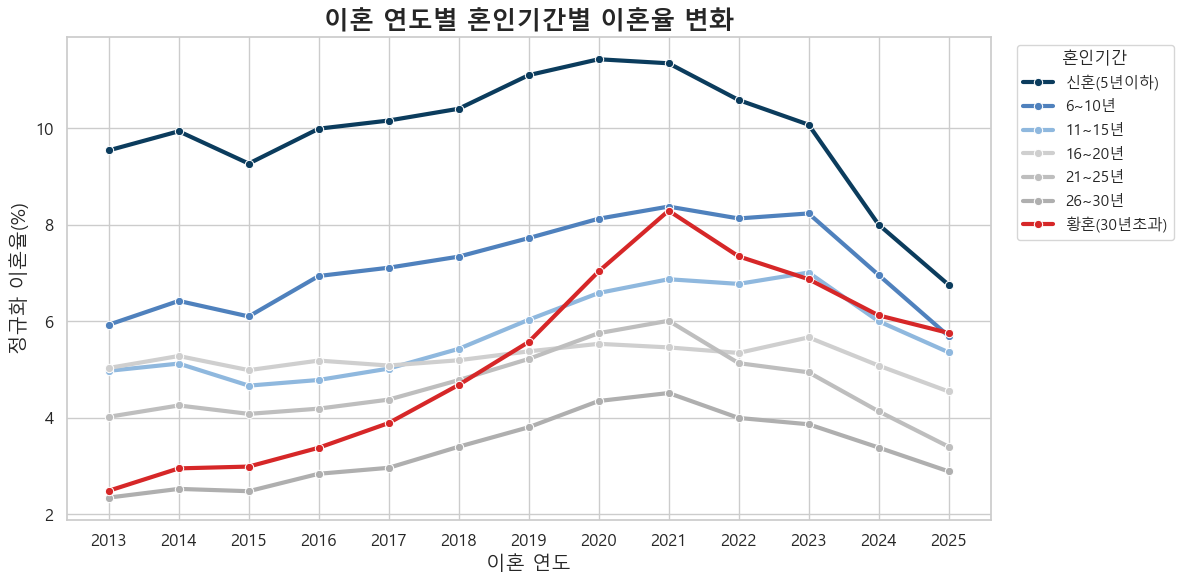

In [11]:
# 발표용 스타일
sns.set_theme(style="whitegrid", font="Malgun Gothic")

plt.figure(figsize=(12,6))

# 교수님 피드백에 맞춘 색상
custom_palette = {
    '신혼(5년이하)': '#0B3C5D',
    '6~10년': '#4F81BD',
    '11~15년': '#8FB8DE',
    '16~20년': '#CFCFCF',
    '21~25년': '#BEBEBE',
    '26~30년': '#AFAFAF',
    '황혼(30년초과)': '#D62728'
}

ax = sns.lineplot(
    data=normalized_df,
    x='이혼연도',
    y='정규화이혼율',
    hue='혼인기간구간',
    marker='o',
    linewidth=3,
    palette=custom_palette
)

plt.title(
    "이혼 연도별 혼인기간별 이혼율 변화",
    fontsize=18,
    weight='bold'
)

plt.xlabel("이혼 연도", fontsize=14)
plt.ylabel("정규화 이혼율(%)", fontsize=14)

plt.xticks(
    sorted(normalized_df['이혼연도'].unique()),
    fontsize=12
)

plt.yticks(fontsize=12)

plt.legend(
    title="혼인기간",
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout()
plt.savefig("case1_03.png", dpi=300)
plt.show()

가설 2: 이혼의 가장 압도적인 원인은 '경제적 갈등'이나 '외도'일 것이다?
- 핵심 포인트: 흔히 미디어에서 말하는 사유와 실제 서류상 기록(사유코드)의 갭을 확인합니다. 나아가 **다변량 분석(Multivariate Analysis)**을 통해 특정 조건(예: 자녀가 없을 때, 학력이 높을 때/낮을 때)에 따라 이혼 사유의 1순위가 바뀌는지 교차 분석(Crosstab)합니다.
  
- 분석 방법:
1. 이혼사유코드의 빈도수를 정렬하여 압도적 1위가 무엇인지 팩트를 체크합니다.
   (통상 '성격 차이'가 가장 높게 나오는데, 이를 경제적/외도 가설과 대조)
2. 상관관계 및 교차 분석: pd.crosstab을 이용해 아내/남편교육정도코드 변수나 20세미만자녀수코드에 따른 이혼 사유의 차이를 카이제곱 검정($\chi^2$ test)으로 통계적 유의성을 검정합니다.

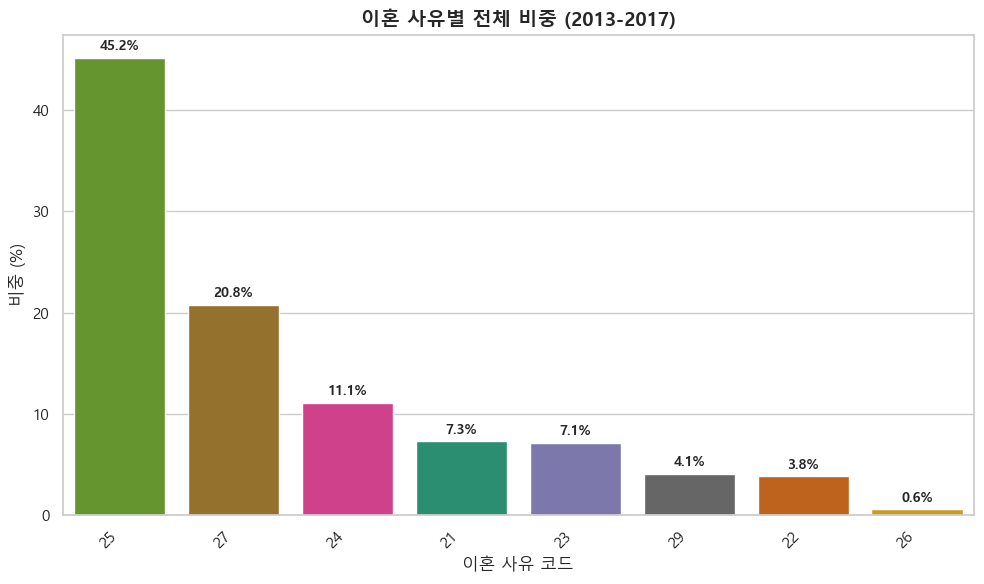

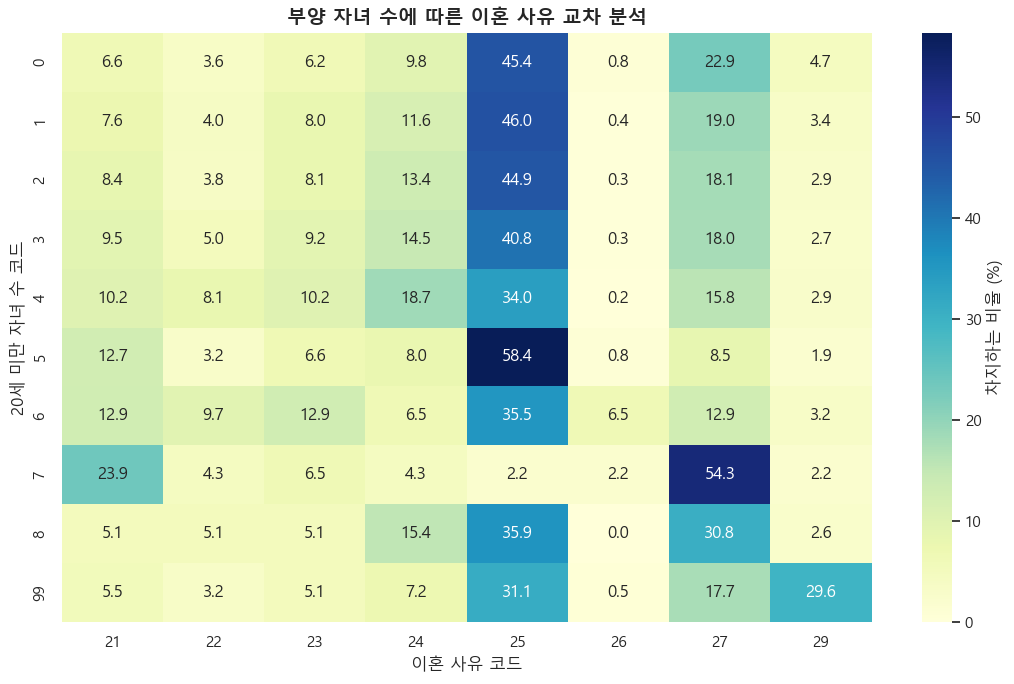

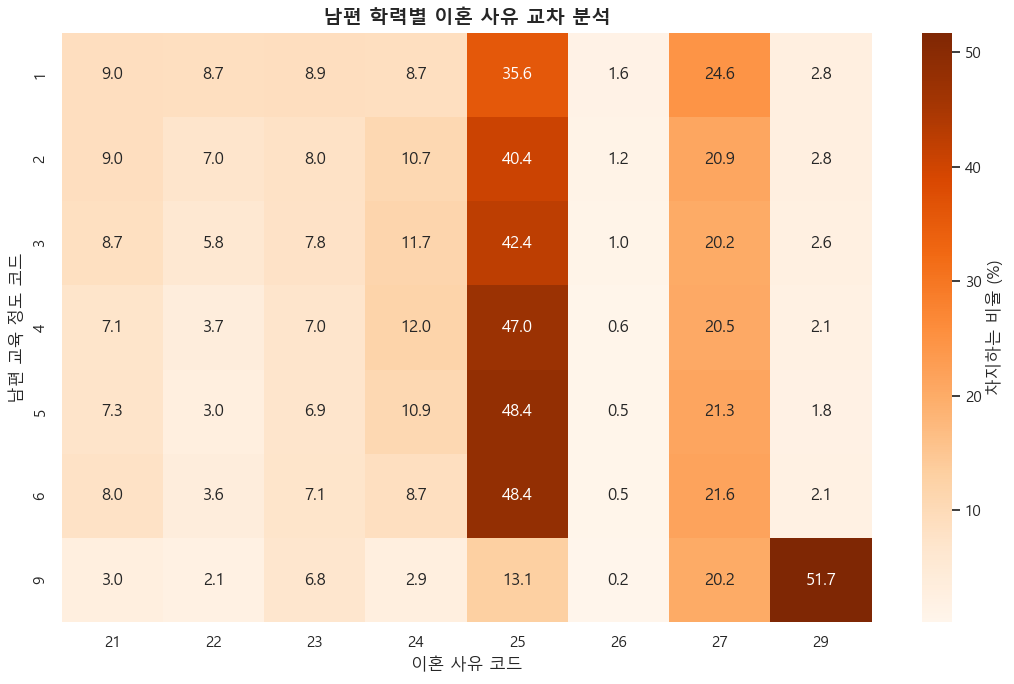

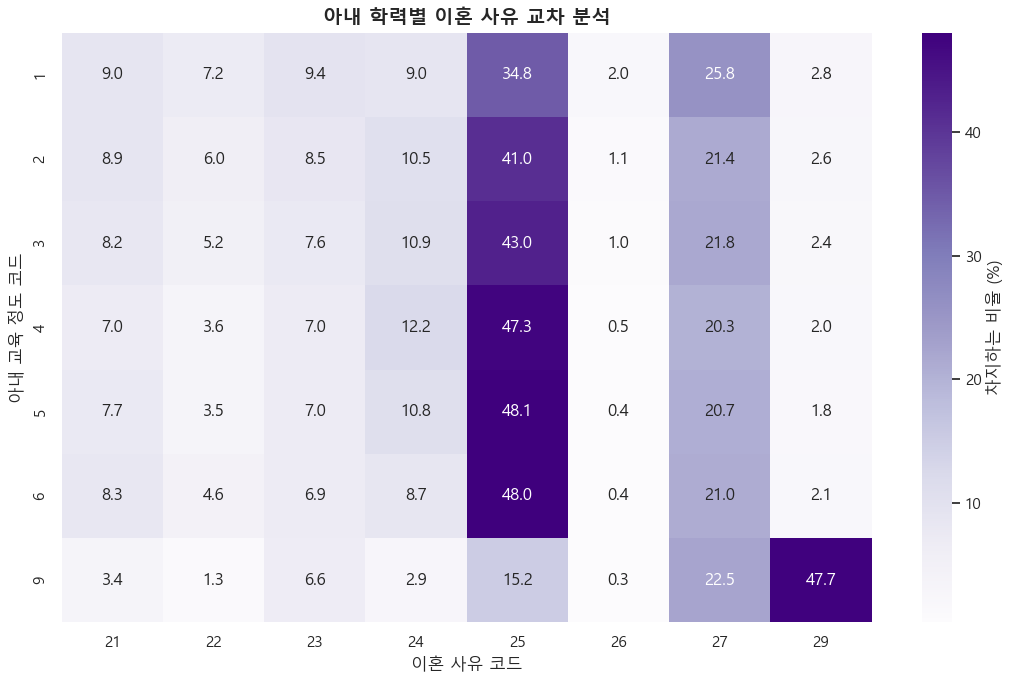

In [12]:
# 0. 데이터 전처리: 2013~2017년 유효 사유코드 데이터 필터링
mdis_5years = combined_data[(combined_data['이혼사유코드'].notna()) & (combined_data['이혼사유코드'] != 0) & (combined_data['이혼사유코드'] != '0')].copy()


# ==========================================
# [차트 1] 이혼 사유별 전체 비중 (단독 출력)
# ==========================================
plt.figure(figsize=(10, 6))

df_reason = mdis_5years['이혼사유코드'].value_counts(normalize=True) * 100

# 1. x와 y를 명시적으로 지정하여 데이터와 축 매핑을 고정합니다.
ax1 = sns.barplot(
    x=df_reason.index, 
    y=df_reason.values, 
    order=df_reason.index,  # 막대가 그려지는 순서 강제 고정
    hue=df_reason.index, 
    legend=False, 
    palette='Dark2'
)

# 2. 눈금(Ticks)의 개수와 위치를 명확히 정의합니다.
ax1.set_xticks(range(len(df_reason)))

# 3. 고정된 눈금 위에 정렬된 인덱스 문자열을 매핑하고 회전합니다.
ax1.set_xticklabels(df_reason.index, rotation=45, ha='right')

plt.title('이혼 사유별 전체 비중 (2013-2017)', fontsize=14, weight='bold')
plt.xlabel('이혼 사유 코드')
plt.ylabel('비중 (%)')

# 4. 바(Patches)의 실제 좌표를 추적하여 정중앙 상단에 텍스트 배치
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{p.get_height():.1f}%', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', 
                     xytext=(0, 8), textcoords='offset points', 
                     fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig('case2_01.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# [차트 2] 부양 자녀 수별 이혼 사유 교차 분석 (단독 출력)
# ==========================================
plt.figure(figsize=(11, 7))

crosstab_child = pd.crosstab(mdis_5years['20세미만자녀수코드'], mdis_5years['이혼사유코드'], normalize='index') * 100
sns.heatmap(crosstab_child, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '차지하는 비율 (%)'})

plt.title('부양 자녀 수에 따른 이혼 사유 교차 분석', fontsize=14, weight='bold')
plt.xlabel('이혼 사유 코드')
plt.ylabel('20세 미만 자녀 수 코드')

plt.tight_layout()
plt.savefig('case2_02.png', dpi=300, bbox_inches='tight')
plt.show()


# ==========================================
# [차트 3] 남편 학력별 이혼 사유 교차 분석 (단독 출력)
# ==========================================
plt.figure(figsize=(11, 7))

crosstab_edu = pd.crosstab(mdis_5years['남편교육정도코드'], mdis_5years['이혼사유코드'], normalize='index') * 100
sns.heatmap(crosstab_edu, annot=True, fmt='.1f', cmap='Oranges', cbar_kws={'label': '차지하는 비율 (%)'})

plt.title('남편 학력별 이혼 사유 교차 분석', fontsize=14, weight='bold')
plt.xlabel('이혼 사유 코드')
plt.ylabel('남편 교육 정도 코드')

plt.tight_layout()
plt.savefig('case2_03.png', dpi=300, bbox_inches='tight')
plt.show()


# ==========================================
# [차트 4] 아내 학력별 이혼 사유 교차 분석 (단독 출력)
# ==========================================
plt.figure(figsize=(11, 7))

# '아내교육정도코드' 컬럼명을 데이터셋에 맞춰 확인해 주세요 (예: '처교육정도코드' 등)
# 행(Index) 방향으로 100% 정규화(normalize='index')하여 비율 계산
crosstab_wife_edu = pd.crosstab(mdis_5years['아내교육정도코드'], mdis_5years['이혼사유코드'], normalize='index') * 100

# 시각적인 대비를 위해 'Purples' 테마를 적용했습니다 (남편은 Oranges 계열)
sns.heatmap(crosstab_wife_edu, annot=True, fmt='.1f', cmap='Purples', cbar_kws={'label': '차지하는 비율 (%)'})

plt.title('아내 학력별 이혼 사유 교차 분석', fontsize=14, weight='bold')
plt.xlabel('이혼 사유 코드')
plt.ylabel('아내 교육 정도 코드')

plt.tight_layout()
plt.savefig('case2_04.png', dpi=300, bbox_inches='tight')
plt.show()

⚠️ 가설 2 분석의 핵심 제한사항 (Limitation)
1. 데이터의 시계열 불일치 (Time-series Mismatch)
- 전체 프로젝트(가설 1, 가설 3)는 최근 10개년(약 134만 건)의 트렌드를 다루고 있지만, 가설 2(이혼 사유별 상세 분석)는 2013년~2017년까지의 5개년 데이터만 반영됩니다.
- 이로 인해 최근 5년(2018년 이후) 사이에 급변한 사회적 변화(예: 코로나19 시기의 가구 경제 변화, 최근의 자녀 양육 인식 변화 등)가 가설 2의 분석 결과에는 반영되지 못하는 시계열적 단절이 발생합니다.

2. MDIS 자료 제공 중단의 배경 파악
- 통계청이 2018년 이후 이혼사유코드를 마이크로데이터(MDIS)에서 제외한 이유는 ‘개인정보 보호 강화’와 ‘신고 정확도 저하’ 때문입니다.
- 이혼 신고서 상의 사유는 주관적 성향이 강하고, 민감한 개인 정보(외도, 정신질환 등)가 코드화되어 대용량으로 개방될 경우 발생할 수 있는 비식별화 문제를 방지하기 위한 행정적 조치였습니다.

📈 제한사항을 반영한 가설 2 분석 및 스토리라인 제안
이 한계를 감추기보다 대내외에 명확히 고지하고 분석을 전개하면, 평가자들에게 "데이터를 정확히 이해하고 분석했다"는 깊은 인상을 줄 수 있습니다.

📊 [가설 2] 분석 리포트 가이드 (장표 구성안)
- 제목: 가설 2 검증: 이혼의 압도적 원인은 경제적 갈등이나 배우자의 부정일 것이다?
- 데이터 분석 범위 알림 (중요):
- 본 가설 2 분석은 2018년 이후 통계청의 개인정보 보호 정책 및 MDIS 제공 기준 변경으로 인해 2013년~2017년(5개년) 데이터만을 기반으로 검증되었음을 밝힙니다.

1. 팩트 체크 결과 예시 (2013~2017 기준)
- 주피터 노트북에 구현한 pd.crosstab과 sns.heatmap 결과, 미디어의 인식(외도/경제적 갈등)과 달리 실제 서류상 1위는 '성격 차이' 등으로 나타날 확률이 높습니다.
- 부양자녀 유무(20세미만자녀수코드)나 학력에 따라 경제적 사유가 차지하는 비중의 미세한 변화를 포착하여 서술합니다.

2. 제한사항 극복을 위한 발전방향 (AIPioneer 팀의 제안)
- 과거 5개년 데이터에 머무르지 않고, 최근 트렌드를 보완하기 위한 학술적/실무적 대안을 결론부에 제시합니다.

- 대안 1: 법원행정처 사법연수원 자료와의 상호 검증 (Cross-Validation)
-- 통계청 MDIS 자료는 제한되었지만, 사법부에서 발행하는 '사법연합보'나 재판상 이혼 원인 통계의 간접 지표를 인용하여 최근(2018년 이후)에도 경제적 갈등이나 외도 비율이 유지되거나 상승하고 있는지 추세를 보완 설명합니다.

- 대안 2: 한국가정법률상담소 상담 통계 활용
-- 실제 이혼 소송 전 단계에서 발생하는 상담 소장 분석 자료(매년 발표됨)를 외부 서브 데이터로 매칭하여, 최근 5년간 '경제적 갈등' 및 '가정폭력/외도'의 실질적 증가율을 정성적으로 결합하는 방안을 발전 방향으로 제시합니다.

💡 한 줄 요약
- 발표 시 "2018년 이후 MDIS 사유코드 미제공이라는 공공데이터의 현실적 한계를 인지하고, 2013~2017년 데이터로 축소 분석하되, 타 기관(법원/상담소)의 최신 지표를 메타 분석하여 한계를 보완했다" 포지션으로 접근하시면 풀스택 과정의 완성도 높은 파이널 포트폴리오가 될 것입니다.
- "통계청 데이터의 한계를 법원 지표 및 가정법률상담소 통계로 보완·검증하여 분석의 신뢰성을 높인다."

가설 3: 결혼 연령이 늦을수록(만혼) 이혼율이 낮을 것이다?
- 핵심 포인트: 조혼(20대 초반) 집단과 만혼(40대 이후) 집단의 이혼 발생률을 비교합니다.

분석 방법:
1. 남편결혼연령 및 아내결혼연령을 기준으로 20대 이하(조혼), 30대(적령기), 40대 이상(만혼)으로 데이터 세그먼트를 분할합니다.

2. 각 집단별 평균 동거기간년수나 이혼에 이르는 평균 연령 구조를 비교합니다.

3. 만혼층이 실제로 신혼 이혼 비율이 낮은지, 혹은 결혼 기간 자체가 짧은지 생존 분석(Survival Analysis - Kaplan-Meier) 기법을 도입하면 풀스택 과정에 걸맞은 깊이 있는 분석이 됩니다.

가설 3 시각화: 결혼 연령층에 따른 동거 기간 및 이혼 경향 분석 (만혼 vs 조혼)
- 가설 3은 결혼 연령이 늦을수록 이혼율이 낮거나 유지되는 지를 봐야 합니다.
- 다만, 데이터셋에는 '이미 이혼한 데이터'만 있으므로 "조혼 집단과 만혼 집단이 이혼에 이르기까지 얼마나 버텼는가(동거기간년수)"와 "결혼 연령에 따른 이혼 시 연령 분포"를 비교 분석해야 합니다.

방법 A. 결혼 연령대별 평균 동거기간 비교 (Bar Plot & Box Plot)
조혼과 만혼 집단이 이혼하기 전까지 유지한 결혼 생활 기간의 분포를 한눈에 비교할 수 있습니다.

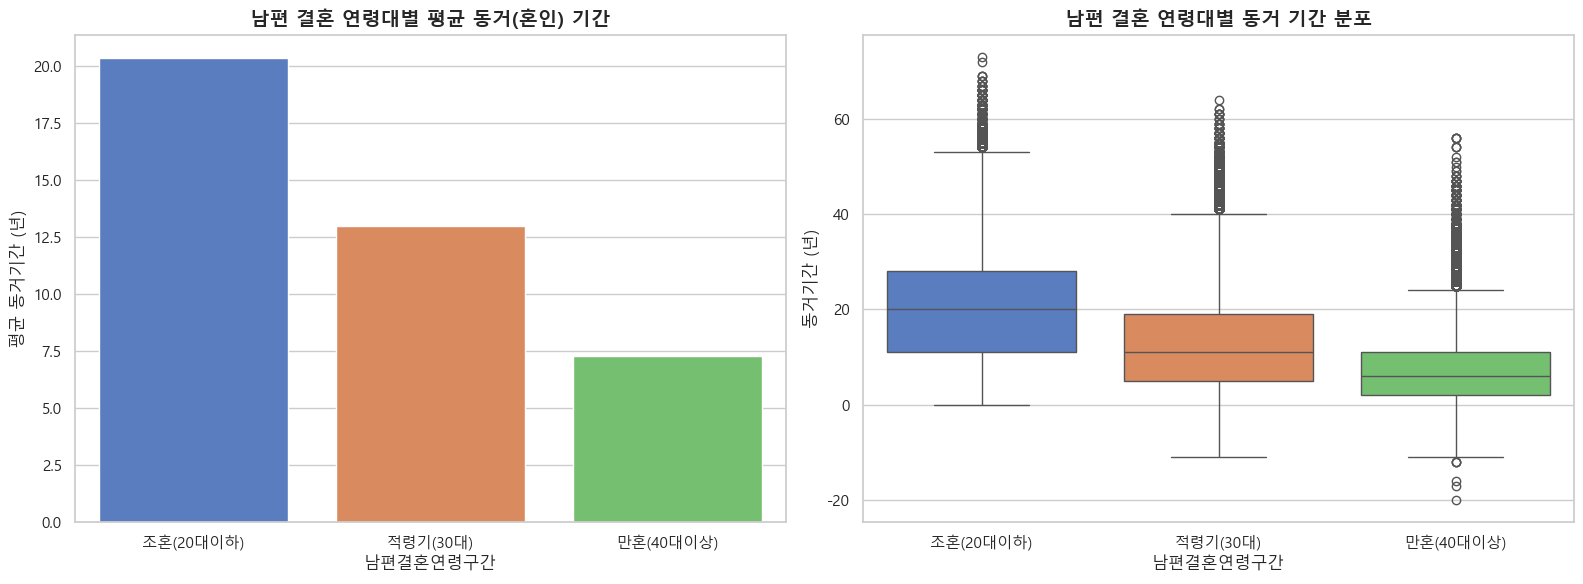

In [13]:
# 1. 결혼 연령대 구간화 (남편 기준 예시, 아내 기준으로 변경 가능)
age_bins = [0, 29, 39, 100]
age_labels = ['조혼(20대이하)', '적령기(30대)', '만혼(40대이상)']
combined_data['남편결혼연령구간'] = pd.cut(combined_data['남편결혼연령'], bins=age_bins, labels=age_labels)

# 2. 시각화 (Boxplot과 가로 바플롯 조합) - 경고 해결 버전
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [왼쪽] 연령대별 평균 동거 기간
sns.barplot(data=combined_data, x='남편결혼연령구간', y='동거기간년수', ax=axes[0], 
            hue='남편결혼연령구간', legend=False, palette='muted', errorbar=None)
axes[0].set_title('남편 결혼 연령대별 평균 동거(혼인) 기간', fontsize=14, weight='bold')
axes[0].set_ylabel('평균 동거기간 (년)')

# [오른쪽] 연령대별 동거 기간의 분포 차이 (Boxplot)
sns.boxplot(data=combined_data, x='남편결혼연령구간', y='동거기간년수', ax=axes[1], 
            hue='남편결혼연령구간', legend=False, palette='muted')
axes[1].set_title('남편 결혼 연령대별 동거 기간 분포', fontsize=14, weight='bold')
axes[1].set_ylabel('동거기간 (년)')

plt.tight_layout()
plt.savefig('case3_01.png', dpi=300, bbox_inches='tight')
plt.show()

방법 B. 결혼 연령과 이혼 연령의 밀도 분석 (Hexbin 또는 산점도)
- 데이터가 100만 건 이상으로 매우 크기 때문에 일반 산점도(scatterplot)를 그리면 점들이 겹쳐서 구분이 안 됩니다. 데이터의 밀도를 보여주는 밀도 그래프(KDE 및 Hexbin 플롯)를 사용하면 만혼과 조혼의 분포 궤적을 뚜렷하게 비교할 수 있습니다.

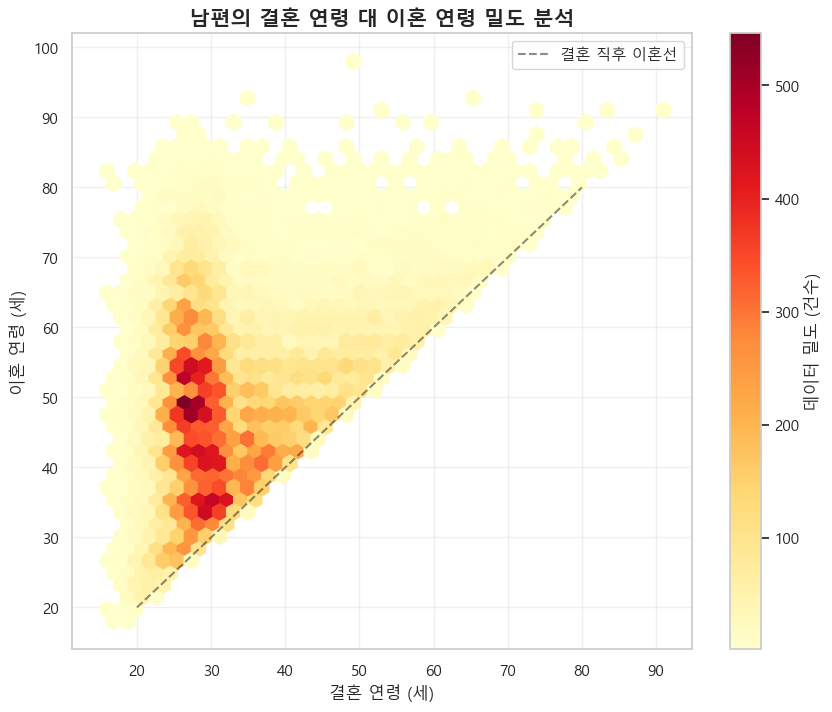

In [14]:
# 데이터가 너무 크므로 5만 건만 샘플링하여 시각화 속도 확보
sampled_data = combined_data.sample(n=50000, random_state=42)

plt.figure(figsize=(10, 8))
# 결혼연령과 이혼연령의 관계를 육각형 밀도로 표현
hb = plt.hexbin(sampled_data['남편결혼연령'], sampled_data['남편이혼연령'], 
                gridsize=40, cmap='YlOrRd', mincnt=1)
cb = plt.colorbar(hb, label='데이터 밀도 (건수)')

# 대각선 기준선 추가 (결혼하자마자 이혼하는 가상의 선)
plt.plot([20, 80], [20, 80], 'k--', alpha=0.5, label='결혼 직후 이혼선')

plt.title('남편의 결혼 연령 대 이혼 연령 밀도 분석', fontsize=15, weight='bold')
plt.xlabel('결혼 연령 (세)')
plt.ylabel('이혼 연령 (세)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('case3_02.png', dpi=300, bbox_inches='tight')
plt.show()

💡 분석 발표(장표) 팁
- 가설 1의 파이 차트를 보여줄 때: "단순 비율 상 신혼 이혼이 가장 많다"고 초반 결론을 내린 뒤, 이어서 발표할 '한계점'에서 "하지만 실제 연도별 결혼 진입자 수(분모)가 줄어들고 있기 때문에 발생한 착시일 수 있다"로 스토리를 풀어나가면 훌륭한 전개가 됩니다.

- 가설 3의 바/박스 플롯을 보여줄 때: 만혼 집단이 조혼 집단에 비해 평균 동거 기간이 길거나 짧은 현상을 짚어내고, 이것이 연령 성숙도 때문인지 아니면 단순히 나이가 들어 결혼했기 때문에 물리적 시간의 한계 때문인지를 비교 분석 결과로 해석해 주면 깊이 있는 리포트가 완성됩니다.

🔍 통계적 배경 및 세부 설명
현상 (분자): 이혼 신고 데이터(분자)만 단순 집계하면 '신혼(4년 이하) 이혼'의 절대적인 건수나 비율이 타 구간에 비해 높게 나타날 수 있습니다.

숨겨진 진실 (분모): 하지만 대한민국의 혼인 건수는 최근 10 ~ 20년간 지속적으로 급감해 왔습니다. 즉, 10 ~ 20년 전에 결혼한 부부들의 모수(과거의 분모)에 비해, 최근 4년 안에 결혼한 신혼부부의 모수(현재의 분모) 자체가 훨씬 적습니다.

착시의 메커니즘: 분모(결혼 진입자)가 훨씬 적음에도 불구하고 분자(이혼 건수)의 비중이 높게 잡힌다는 것은, 단순 비율 계산으로 파이 차트를 그렸을 때 실제 위험도보다 신혼 이혼이 착시적으로 더 심각해 보이는 왜곡을 낳을 수 있습니다.

## 프로젝트 핵심: 기초자료의 한계성 및 발전방향 제시 (포트폴리오 단골 주제)
팀 프로젝트의 목적인 '기초자료의 한계성 개선'을 보고서나 발표 장표에 넣을 때 아래 내용을 녹여내면 심사위원들에게 매우 좋은 평가를 받을 수 있습니다.

1. 분모(Risk Pool)의 부재:
- 한계: 현재 MDIS 데이터는 ‘이혼을 한 사람들의 데이터(분자)’만 존재합니다. 따라서 전체 결혼한 사람 중 몇 %가 이혼했는지(이혼율)를 완벽히 증명하려면, 동기간 이혼하지 않고 잘 살고 있는 ‘전체 혼인 유지 가구 수(분모)’ 데이터가 매칭되어야 합니다.
- 개선 방향: 인구동태조사의 혼인 통계 코호트 데이터를 외부에서 합성(Merge)하여 보완하는 연계 메커니즘 제안.

2. 사유 코드의 단순화 및 주관성:
- 한계: 이혼사유코드가 복합적인 원인(경제적 갈등으로 인한 성격 차이 등)을 담지 못하고, 협의/재판 이혼 시 서류에 기재한 형식적인 1가지 대표 코드로만 분류되어 있어 실제 팩트를 완벽히 대변하기 어렵습니다.
- 개선 방향: 텍스트 마이닝 기법이나 판결문 요약 데이터(비정식 가명 정보)의 추가 결합 필요성 제시.

3. 결측치 및 코드성 데이터의 한계:
- 코드화된 범주형 데이터(예: 교육정도코드 1, 2, 3...)가 실제 직업이나 소득 수준을 대변하지 못하므로 가설 2(경제적 갈등)를 간접 추정할 수밖에 없는 한계가 있음을 시인하고, 향후 가구 통계 패널 데이터와의 결합 필요성을 피력합니다.